# 📡 TelecomX LATAM — Análisis de Evasión de Clientes (Churn)

---

## 📄 Informe Final

### 🔹 Introducción

**TelecomX** es una empresa de telecomunicaciones que opera en América Latina y está enfrentando un creciente problema de **evasión de clientes (Churn)**: una porción significativa de sus suscriptores cancela sus contratos, generando pérdidas considerables en ingresos recurrentes y elevando los costos de adquisición de nuevos clientes.

El objetivo de este análisis es:
- 📥 **Extraer** y entender los datos proporcionados por la empresa.
- 🔧 **Transformar** y limpiar los datos para garantizar su calidad.
- 📊 **Analizar exploratoriamente** los patrones que caracterizan a los clientes que se van versus los que permanecen.
- 💡 **Generar insights** y recomendaciones estratégicas para reducir la tasa de churn.

Los resultados de este análisis serán entregados al equipo de Ciencia de Datos para la construcción de modelos predictivos.

---

# 📌 Extracción

In [3]:
# ── Instalación y carga de librerías ──────────────────────────────────────────
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Configuración visual global
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (10, 5)})

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


In [4]:
# ── Carga del JSON ─────────────────────────────────────────────────────────────
# Si ejecutas en Google Colab, sube el archivo TelecomX_Data.json primero:
# from google.colab import files; files.upload()

JSON_PATH = 'TelecomX_Data.json'   # ← ajustar ruta si es necesario

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

print(f'📦 Registros cargados: {len(raw_data):,}')
print(f'🔑 Claves del primer registro: {list(raw_data[0].keys())}')
print('\nEjemplo del primer registro:')
print(json.dumps(raw_data[0], indent=2, ensure_ascii=False))

📦 Registros cargados: 7,267
🔑 Claves del primer registro: ['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

Ejemplo del primer registro:
{
  "customerID": "0002-ORFBO",
  "Churn": "No",
  "customer": {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "Yes",
    "tenure": 9
  },
  "phone": {
    "PhoneService": "Yes",
    "MultipleLines": "No"
  },
  "internet": {
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "Yes",
    "StreamingTV": "Yes",
    "StreamingMovies": "No"
  },
  "account": {
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Mailed check",
    "Charges": {
      "Monthly": 65.6,
      "Total": "593.3"
    }
  }
}


In [5]:
# ── Normalización: JSON anidado → DataFrame plano ─────────────────────────────
df_raw = pd.json_normalize(
    raw_data,
    sep='_',
    errors='ignore'
)

# Renombrar columnas para mayor legibilidad
df_raw.columns = [
    col.replace('customer_', '')
       .replace('phone_', '')
       .replace('internet_', '')
       .replace('account_', '')
       .replace('Charges_', 'Charges.')
    for col in df_raw.columns
]

print(f'📐 Shape inicial: {df_raw.shape}')
print(f'Columnas: {list(df_raw.columns)}')
df_raw.head(3)

📐 Shape inicial: (7267, 21)
Columnas: ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


# 🔧 Transformación

### 🔹 Limpieza y Tratamiento de Datos

A continuación se describen los pasos realizados para garantizar la calidad del dataset:

1. **Revisión de tipos de datos** y conversión donde sea necesario.
2. **Tratamiento de valores nulos y cadenas vacías** en columnas críticas.
3. **Corrección de tipos**: `Charges.Total` se almacena como string en el JSON original.
4. **Estandarización de variables categóricas** binarias (`Yes/No`) a valores numéricos `1/0`.
5. **Eliminación de duplicados** por `customerID`.
6. **Creación de variables derivadas** útiles para el análisis.

In [6]:
# ── Copia de trabajo ──────────────────────────────────────────────────────────
df = df_raw.copy()

# ── 1. Inspección general ─────────────────────────────────────────────────────
print('=== Info general ===')
df.info()
print('\n=== Primeros nulos / vacíos por columna ===')
print(df.isnull().sum())

=== Info general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          726

In [7]:
# ── 2. Tratar cadenas vacías como NaN ─────────────────────────────────────────
df.replace('', np.nan, inplace=True)

print('Nulos después del reemplazo de vacíos:')
nulos = df.isnull().sum()
print(nulos[nulos > 0])

Nulos después del reemplazo de vacíos:
Churn    224
dtype: int64


In [8]:
# ── 3. Conversión de tipos numéricos ──────────────────────────────────────────
df['Charges.Total']   = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['Charges.Monthly'] = pd.to_numeric(df['Charges.Monthly'], errors='coerce')
df['tenure']          = pd.to_numeric(df['tenure'], errors='coerce')
df['SeniorCitizen']   = pd.to_numeric(df['SeniorCitizen'], errors='coerce')

print('Tipos corregidos:')
print(df[['tenure', 'SeniorCitizen', 'Charges.Monthly', 'Charges.Total']].dtypes)

Tipos corregidos:
tenure               int64
SeniorCitizen        int64
Charges.Monthly    float64
Charges.Total      float64
dtype: object


In [9]:
# ── 4. Eliminar filas sin clasificación de Churn ──────────────────────────────
before = len(df)
df.dropna(subset=['Churn'], inplace=True)
print(f'Filas eliminadas por Churn nulo: {before - len(df)}')

# Imputar Charges.Total faltante con mediana por grupo de Churn
df['Charges.Total'] = df.groupby('Churn')['Charges.Total'].transform(
    lambda x: x.fillna(x.median())
)

# Imputar Charges.Monthly faltante con mediana global
df['Charges.Monthly'].fillna(df['Charges.Monthly'].median(), inplace=True)

# ── 5. Eliminar duplicados ────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset=['customerID'], inplace=True)
print(f'Duplicados eliminados: {before - len(df)}')

print(f'\n✅ Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Nulos restantes: {df.isnull().sum().sum()}')

Filas eliminadas por Churn nulo: 224
Duplicados eliminados: 0

✅ Dataset limpio: 7,043 filas × 21 columnas
Nulos restantes: 0


/tmp/ipykernel_543/2973712830.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Charges.Monthly'].fillna(df['Charges.Monthly'].median(), inplace=True)


In [10]:
# ── 6. Estandarizar variables binarias Yes/No → 1/0 ───────────────────────────
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# Churn como variable numérica (objetivo del modelo)
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Variables binarias convertidas a 1/0 ✅')
print(df[binary_cols + ['Churn_num']].head(3))

Variables binarias convertidas a 1/0 ✅
   Partner  Dependents  PhoneService  PaperlessBilling  OnlineSecurity  \
0        1           1             1                 1             0.0   
1        0           0             1                 0             0.0   
2        0           0             1                 1             0.0   

   OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  \
0           1.0               0.0          1.0          1.0              0.0   
1           0.0               0.0          0.0          0.0              1.0   
2           0.0               1.0          0.0          0.0              0.0   

   Churn_num  
0          0  
1          0  
2          1  


In [11]:
# ── 7. Variables derivadas ────────────────────────────────────────────────────

# Número de servicios adicionales contratados
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_addons'] = df[addon_cols].sum(axis=1)

# Segmento de antigüedad
def tenure_segment(t):
    if pd.isna(t):    return 'Desconocido'
    elif t <= 12:     return '0-12 meses'
    elif t <= 24:     return '13-24 meses'
    elif t <= 48:     return '25-48 meses'
    else:             return '49+ meses'

df['tenure_segment'] = df['tenure'].apply(tenure_segment)

print('Variables derivadas creadas: num_addons, tenure_segment ✅')
df[['customerID', 'Churn', 'tenure', 'tenure_segment', 'num_addons', 'Charges.Monthly']].head(5)

Variables derivadas creadas: num_addons, tenure_segment ✅


,customerID,Churn,tenure,tenure_segment,num_addons,Charges.Monthly
0,0002-ORFBO,No,9,0-12 meses,3.0,65.6
1,0003-MKNFE,No,9,0-12 meses,1.0,59.9
2,0004-TLHLJ,Yes,4,0-12 meses,1.0,73.9
3,0011-IGKFF,Yes,13,13-24 meses,4.0,98.0
4,0013-EXCHZ,Yes,3,0-12 meses,2.0,83.9


In [12]:
# ── Resumen estadístico final ─────────────────────────────────────────────────
print('=== Resumen estadístico (variables numéricas) ===')
df[['tenure', 'Charges.Monthly', 'Charges.Total', 'num_addons']].describe().round(2)

=== Resumen estadístico (variables numéricas) ===


,tenure,Charges.Monthly,Charges.Total,num_addons
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2282.36,2.04
std,24.56,30.09,2265.12,1.85
min,0.00,18.25,18.80,0.00
25%,9.00,35.50,402.22,0.00
50%,29.00,70.35,1400.55,2.00
75%,55.00,89.85,3786.60,3.00
max,72.00,118.75,8684.80,6.00


# 📊 Carga y análisis

### 🔹 Análisis Exploratorio de Datos (EDA)

Se analizan los siguientes aspectos:
- Distribución general del Churn
- Perfil demográfico (género, adulto mayor)
- Impacto del tipo de contrato y método de pago
- Relación entre antigüedad, cargos mensuales y Churn
- Churn por tipo de Internet y servicios adicionales
- Mapa de correlaciones

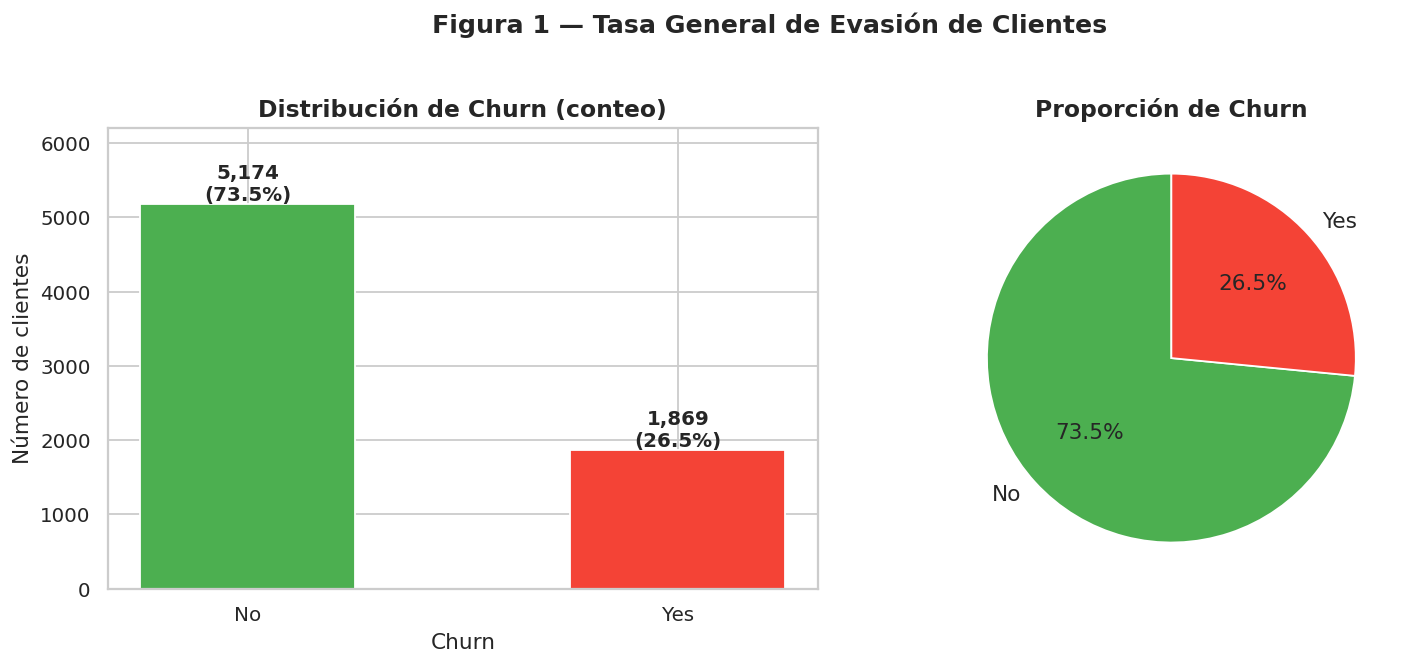

Tasa de Churn global: 26.5%


In [13]:
# ════════════════════════════════════════════════════════════
# GRÁFICO 1 — Distribución general de Churn
# ════════════════════════════════════════════════════════════
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4CAF50', '#F44336']

# Barras
axes[0].bar(churn_counts.index, churn_counts.values,
            color=colors, edgecolor='white', width=0.5)
for i, (val, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, val + 50, f'{val:,}\n({pct:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de Churn (conteo)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Número de clientes')
axes[0].set_ylim(0, churn_counts.max() * 1.2)

# Pie
axes[1].pie(churn_counts.values, labels=churn_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción de Churn', fontsize=13, fontweight='bold')

plt.suptitle('Figura 1 — Tasa General de Evasión de Clientes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Tasa de Churn global: {churn_pct["Yes"]:.1f}%')

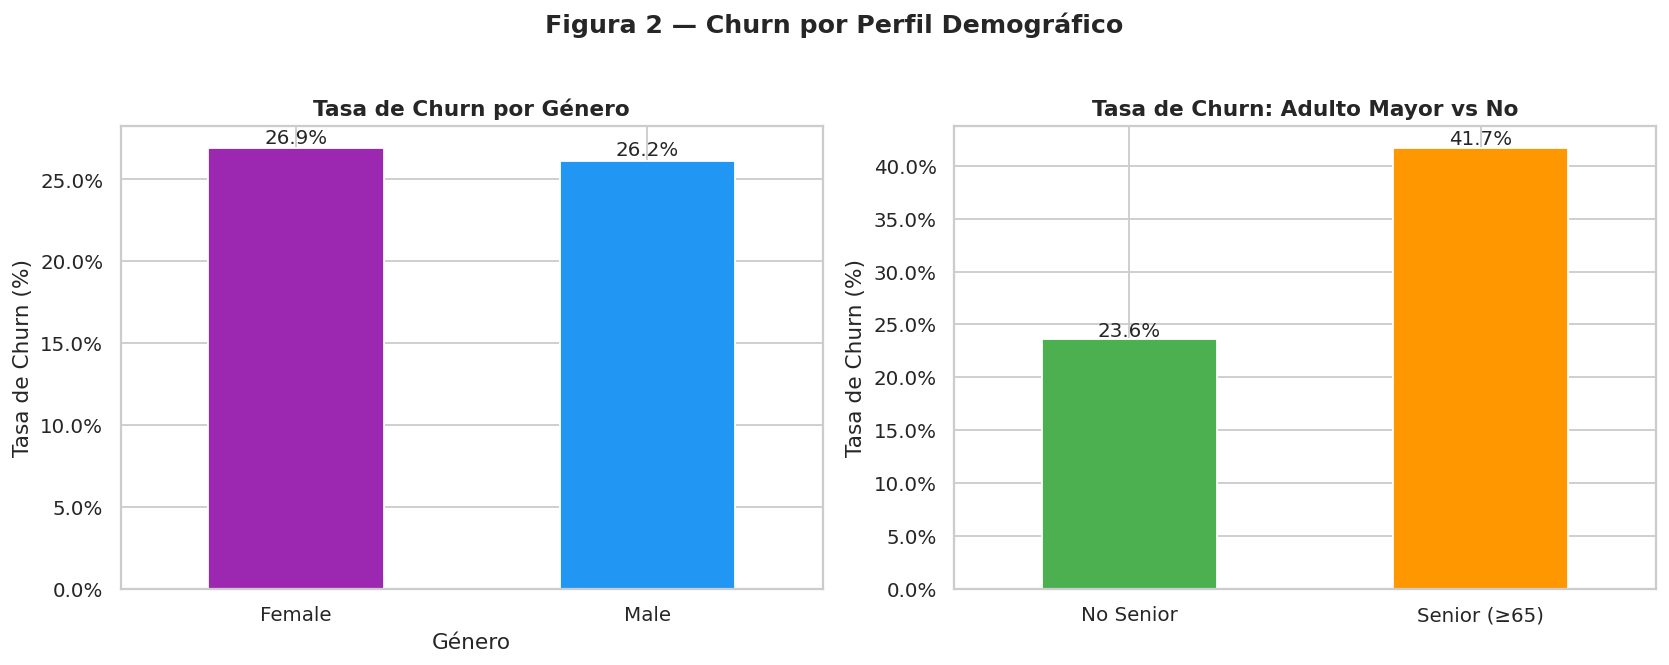

In [14]:
# ════════════════════════════════════════════════════════════
# GRÁFICO 2 — Churn por género y adulto mayor
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Por género
gender_churn = df.groupby('gender')['Churn_num'].mean() * 100
gender_churn.plot(kind='bar', ax=axes[0],
                  color=['#9C27B0', '#2196F3'], edgecolor='white', width=0.5)
axes[0].set_title('Tasa de Churn por Género', fontweight='bold')
axes[0].set_xlabel('Género'); axes[0].set_ylabel('Tasa de Churn (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center', fontsize=11)

# Por adulto mayor
senior_churn = df.groupby('SeniorCitizen')['Churn_num'].mean() * 100
senior_churn.index = ['No Senior', 'Senior (≥65)']
senior_churn.plot(kind='bar', ax=axes[1],
                  color=['#4CAF50', '#FF9800'], edgecolor='white', width=0.5)
axes[1].set_title('Tasa de Churn: Adulto Mayor vs No', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Tasa de Churn (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center', fontsize=11)

plt.suptitle('Figura 2 — Churn por Perfil Demográfico',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

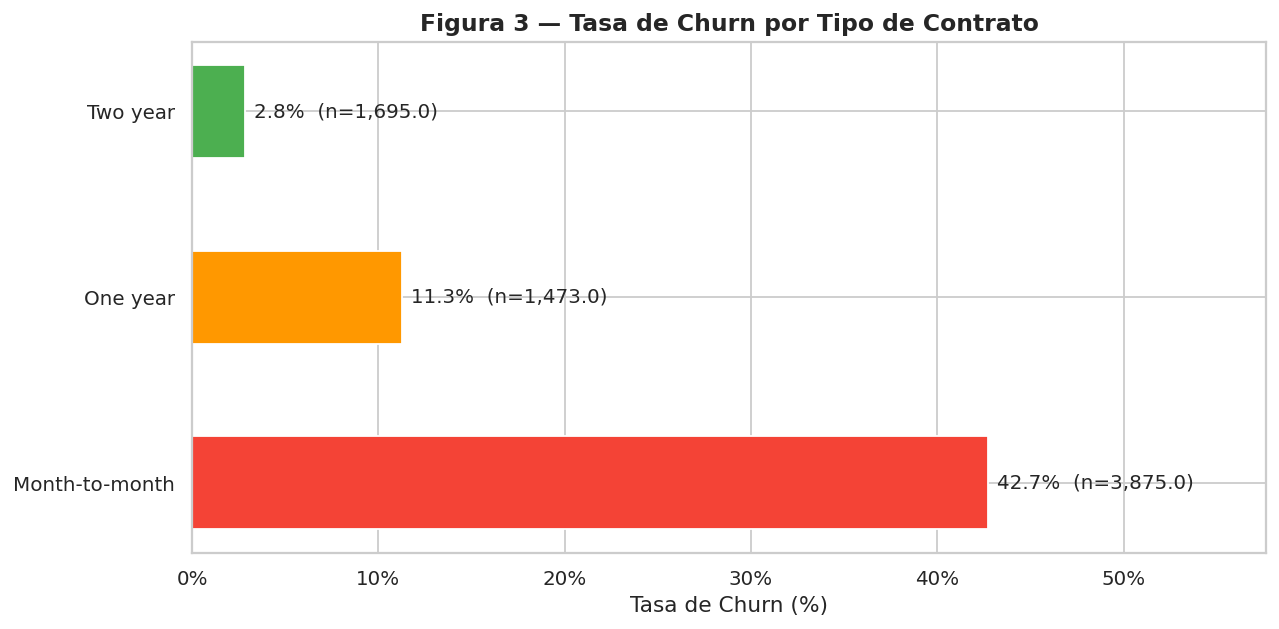

In [15]:
# ════════════════════════════════════════════════════════════
# GRÁFICO 3 — Churn por tipo de contrato
# ════════════════════════════════════════════════════════════
contract_churn = (
    df.groupby('Contract')['Churn_num']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n_clients'})
    .sort_values('churn_rate', ascending=False)
)
contract_churn['churn_rate'] *= 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(contract_churn.index, contract_churn['churn_rate'],
               color=['#F44336', '#FF9800', '#4CAF50'],
               edgecolor='white', height=0.5)
for bar, (idx, row) in zip(bars, contract_churn.iterrows()):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{row['churn_rate']:.1f}%  (n={row['n_clients']:,})",
            va='center', fontsize=11)
ax.set_xlim(0, contract_churn['churn_rate'].max() * 1.35)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Figura 3 — Tasa de Churn por Tipo de Contrato',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de Churn (%)')
plt.tight_layout()
plt.show()

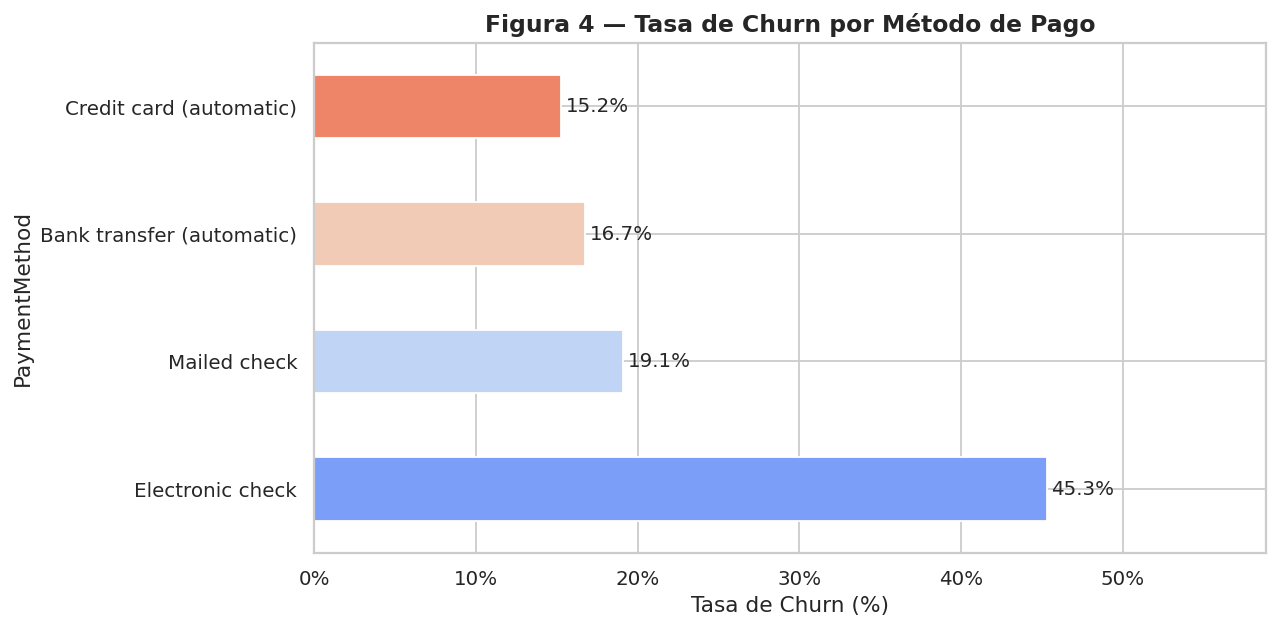

In [16]:
# ════════════════════════════════════════════════════════════
# GRÁFICO 4 — Churn por método de pago
# ════════════════════════════════════════════════════════════
payment_churn = (
    df.groupby('PaymentMethod')['Churn_num']
    .mean()
    .sort_values(ascending=False) * 100
)

palette = sns.color_palette('coolwarm', len(payment_churn))
fig, ax = plt.subplots(figsize=(10, 5))
payment_churn.plot(kind='barh', ax=ax, color=palette, edgecolor='white')
for p in ax.patches:
    ax.text(p.get_width() + 0.3,
            p.get_y() + p.get_height()/2,
            f'{p.get_width():.1f}%', va='center', fontsize=11)
ax.set_xlim(0, payment_churn.max() * 1.3)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Figura 4 — Tasa de Churn por Método de Pago',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de Churn (%)')
plt.tight_layout()
plt.show()

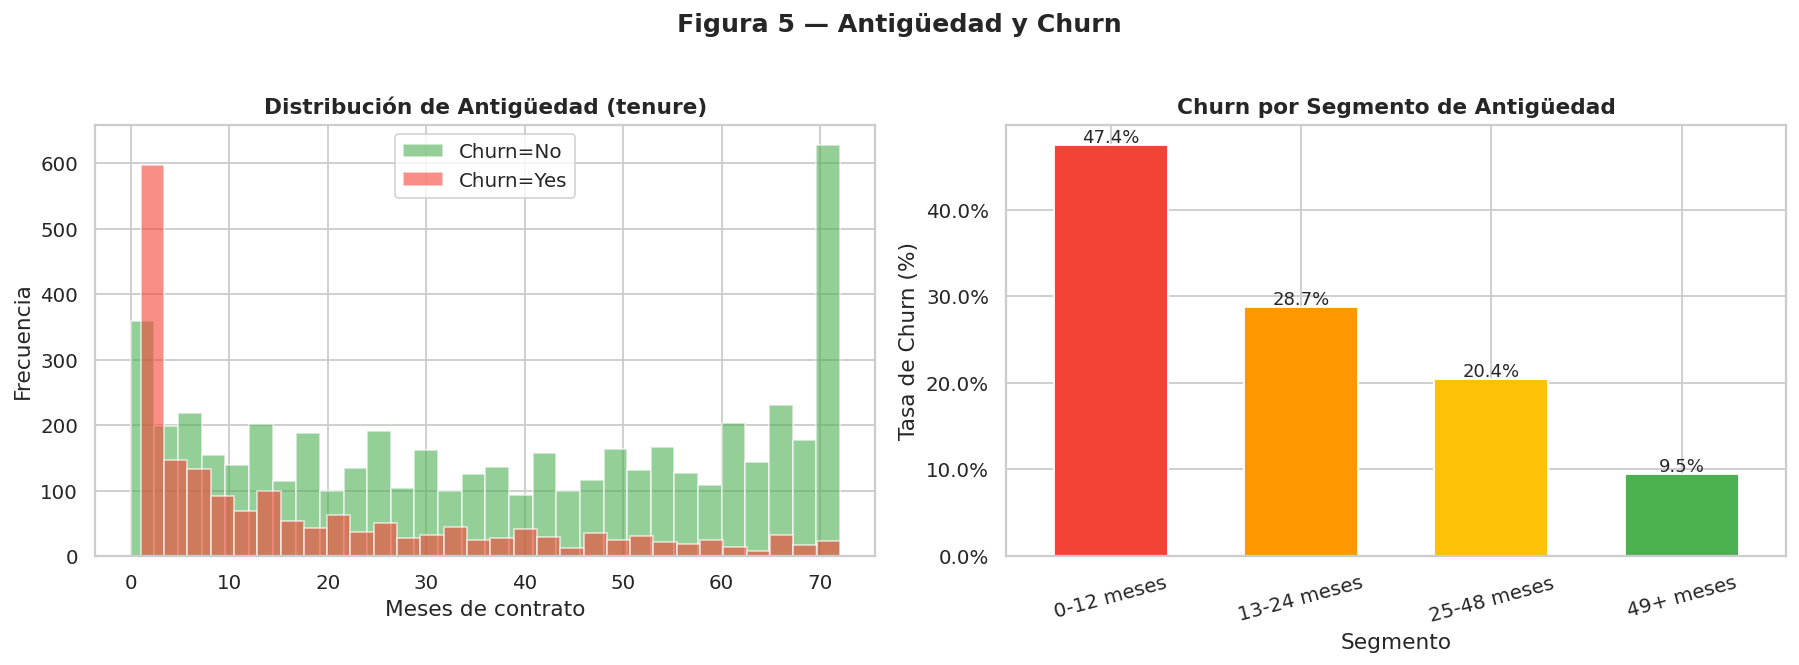

In [17]:
# ════════════════════════════════════════════════════════════
# GRÁFICO 5 — Distribución de tenure y Churn por segmento
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de tenure
for label, color in [('No', '#4CAF50'), ('Yes', '#F44336')]:
    subset = df[df['Churn'] == label]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.6,
                 label=f'Churn={label}', color=color, edgecolor='white')
axes[0].set_title('Distribución de Antigüedad (tenure)', fontweight='bold')
axes[0].set_xlabel('Meses de contrato'); axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Tasa de Churn por segmento de antigüedad
order = ['0-12 meses', '13-24 meses', '25-48 meses', '49+ meses']
seg_churn = (
    df.groupby('tenure_segment')['Churn_num'].mean() * 100
).reindex(order)
seg_churn.plot(kind='bar', ax=axes[1],
               color=['#F44336', '#FF9800', '#FFC107', '#4CAF50'],
               edgecolor='white', width=0.6)
axes[1].set_title('Churn por Segmento de Antigüedad', fontweight='bold')
axes[1].set_xlabel('Segmento'); axes[1].set_ylabel('Tasa de Churn (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 0.3,
                 f'{p.get_height():.1f}%', ha='center', fontsize=10)

plt.suptitle('Figura 5 — Antigüedad y Churn',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_543/1003002151.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Charges.Monthly', ax=axes[0],


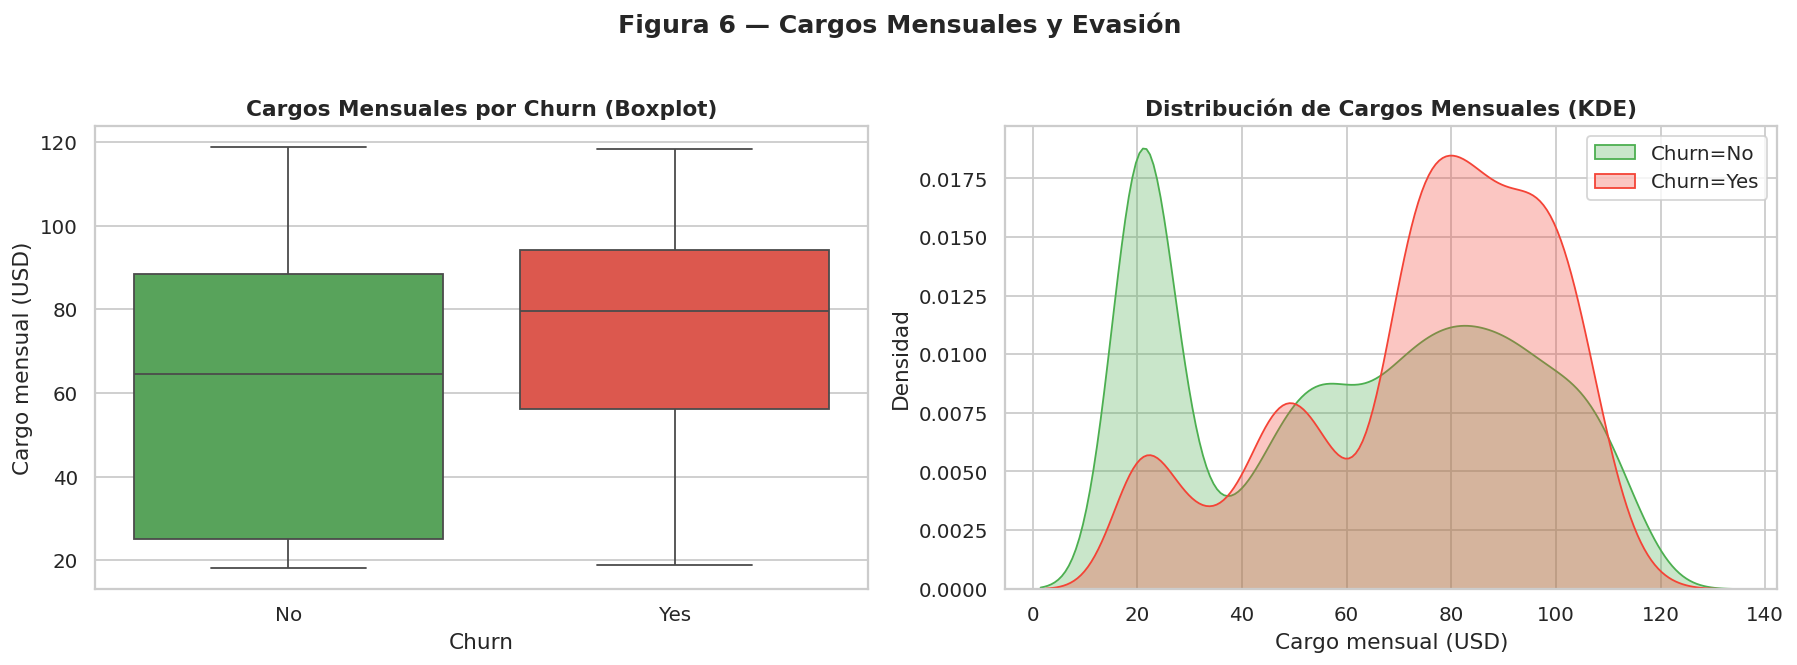

Promedio de cargos mensuales por grupo:
Churn
No     61.27
Yes    74.44
Name: Charges.Monthly, dtype: float64


In [18]:
# ════════════════════════════════════════════════════════════
# GRÁFICO 6 — Cargos mensuales vs Churn (Boxplot + KDE)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df, x='Churn', y='Charges.Monthly', ax=axes[0],
            palette={'No': '#4CAF50', 'Yes': '#F44336'})
axes[0].set_title('Cargos Mensuales por Churn (Boxplot)', fontweight='bold')
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Cargo mensual (USD)')

# KDE
for label, color in [('No', '#4CAF50'), ('Yes', '#F44336')]:
    subset = df[df['Churn'] == label]['Charges.Monthly'].dropna()
    sns.kdeplot(subset, ax=axes[1], label=f'Churn={label}',
                color=color, fill=True, alpha=0.3)
axes[1].set_title('Distribución de Cargos Mensuales (KDE)', fontweight='bold')
axes[1].set_xlabel('Cargo mensual (USD)'); axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('Figura 6 — Cargos Mensuales y Evasión',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Promedio de cargos mensuales por grupo:')
print(df.groupby('Churn')['Charges.Monthly'].mean().round(2))

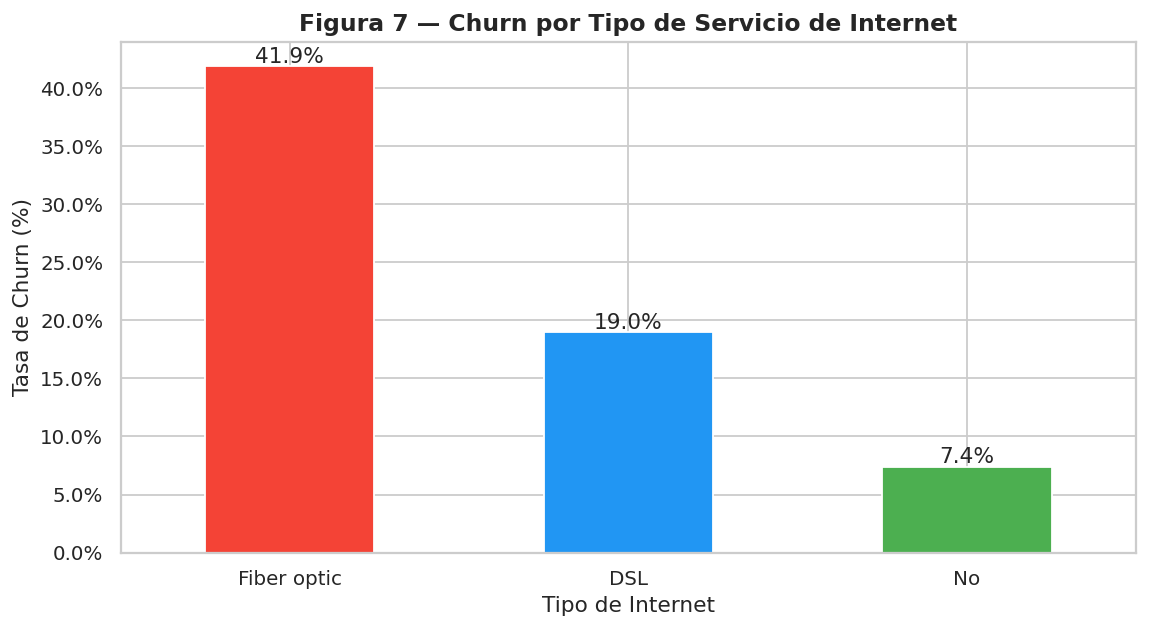

In [19]:
# ════════════════════════════════════════════════════════════
# GRÁFICO 7 — Churn por servicio de Internet
# ════════════════════════════════════════════════════════════
internet_churn = (
    df.groupby('InternetService')['Churn_num'].mean() * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
internet_churn.plot(kind='bar', ax=ax,
                    color=['#F44336', '#2196F3', '#4CAF50'],
                    edgecolor='white', width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Figura 7 — Churn por Tipo de Servicio de Internet',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tipo de Internet'); ax.set_ylabel('Tasa de Churn (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.3,
            f'{p.get_height():.1f}%', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

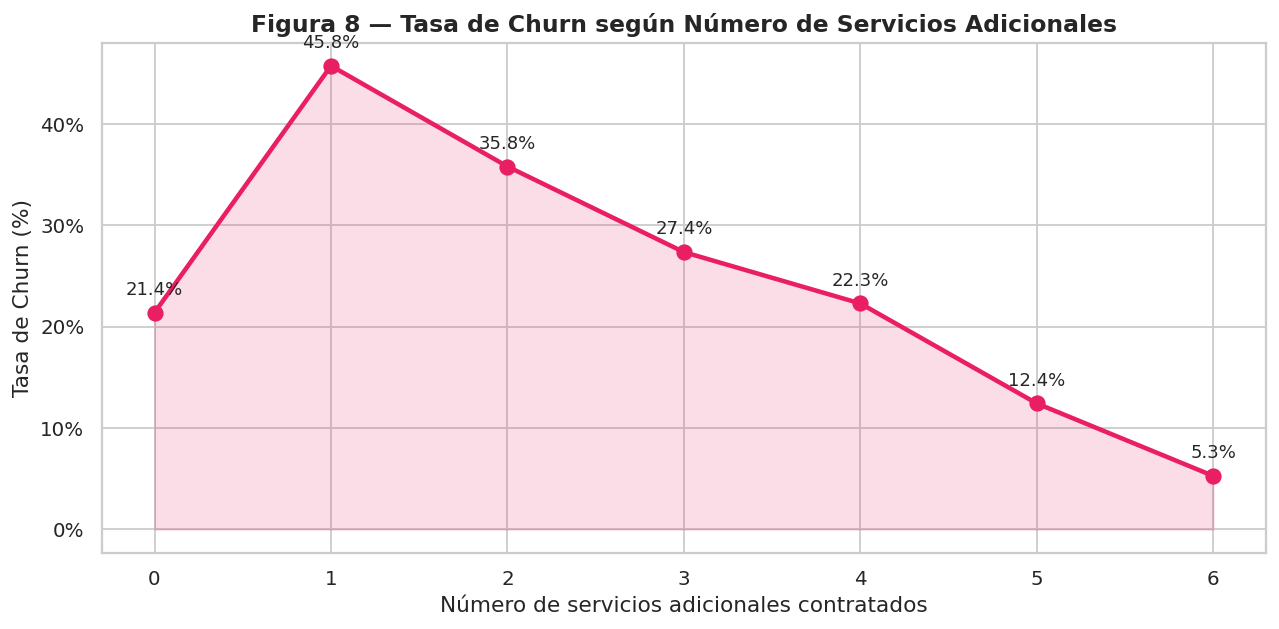

In [20]:
# ════════════════════════════════════════════════════════════
# GRÁFICO 8 — Servicios adicionales y Churn
# ════════════════════════════════════════════════════════════
addon_churn = df.groupby('num_addons')['Churn_num'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(addon_churn.index, addon_churn.values,
        marker='o', color='#E91E63', linewidth=2.5, markersize=8)
ax.fill_between(addon_churn.index, addon_churn.values,
                alpha=0.15, color='#E91E63')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(addon_churn.index)
ax.set_title('Figura 8 — Tasa de Churn según Número de Servicios Adicionales',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Número de servicios adicionales contratados')
ax.set_ylabel('Tasa de Churn (%)')
for x, y in zip(addon_churn.index, addon_churn.values):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

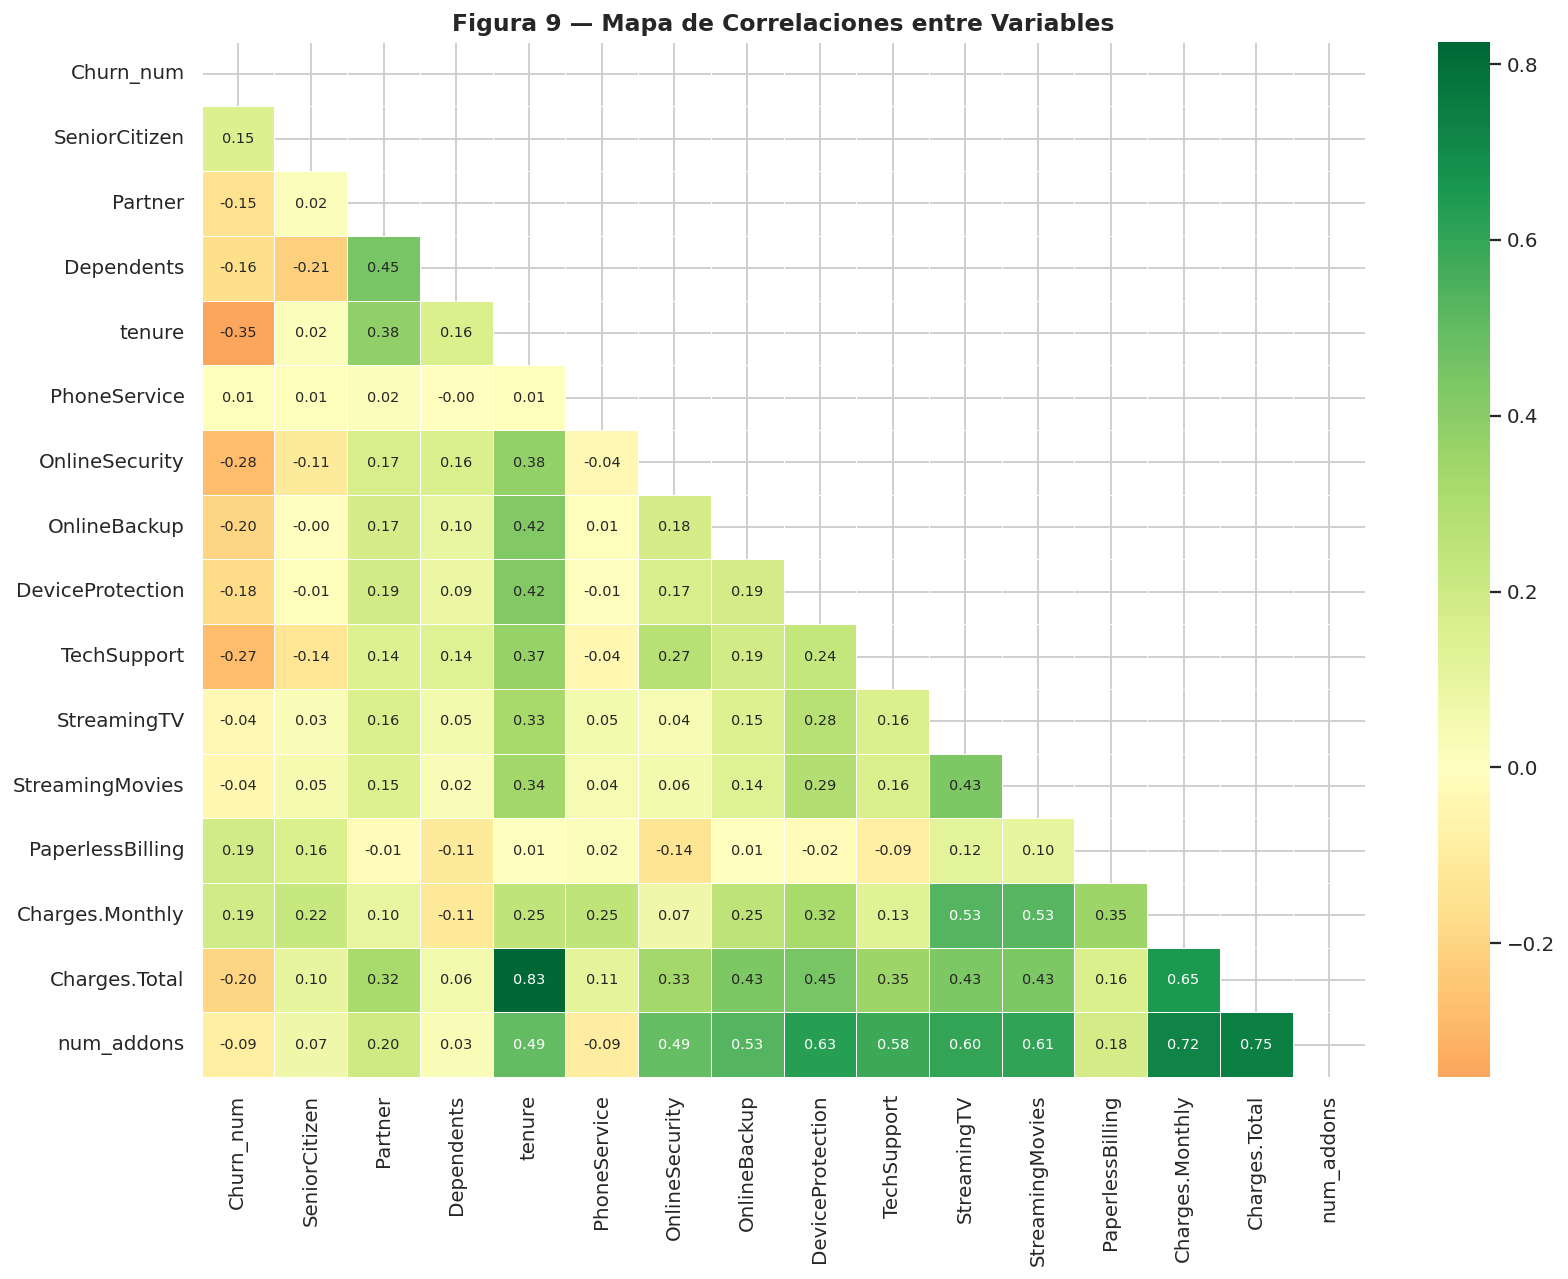

In [21]:
# ════════════════════════════════════════════════════════════
# GRÁFICO 9 — Mapa de calor de correlaciones
# ════════════════════════════════════════════════════════════
corr_cols = [
    'Churn_num', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Charges.Monthly', 'Charges.Total', 'num_addons'
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Figura 9 — Mapa de Correlaciones entre Variables',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

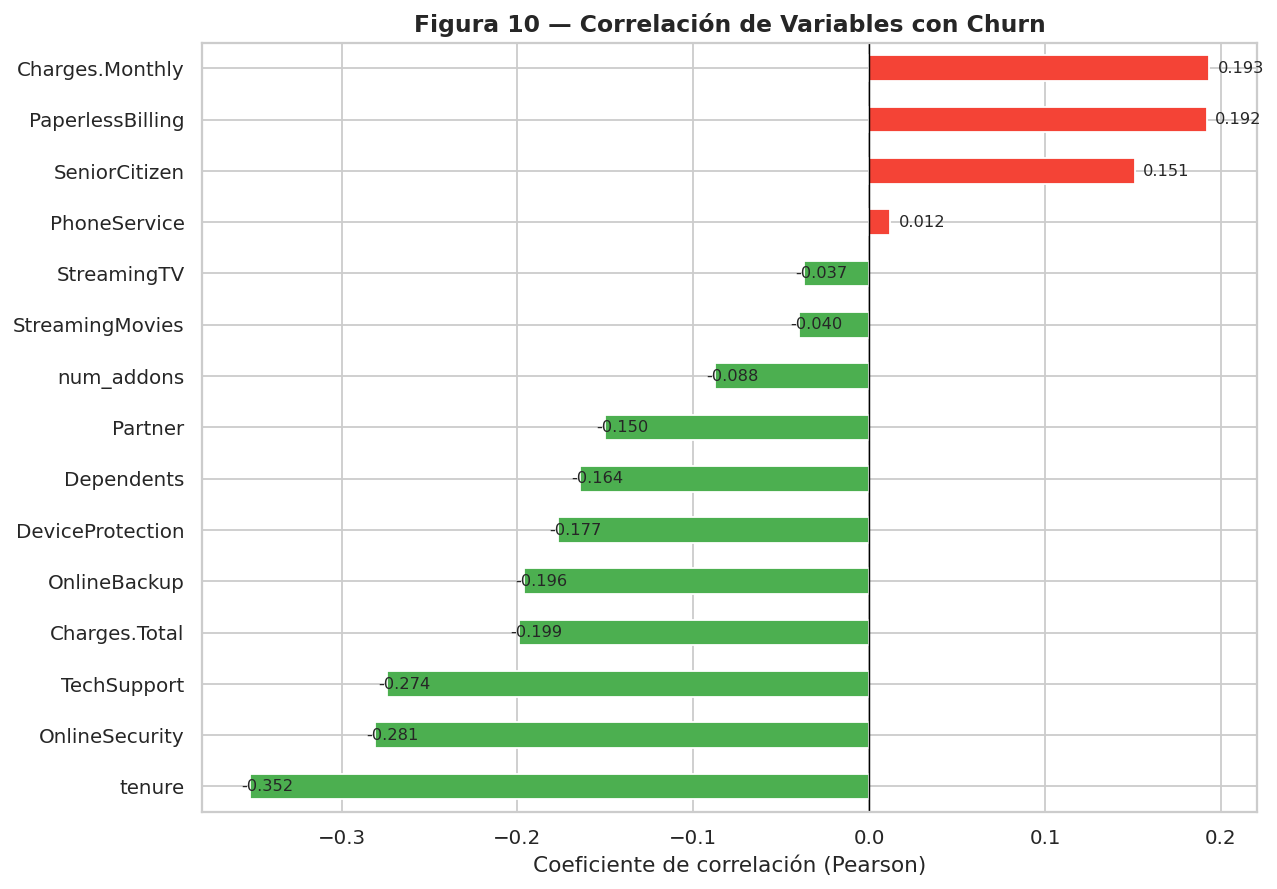

In [22]:
# ════════════════════════════════════════════════════════════
# GRÁFICO 10 — Top correlaciones con Churn
# ════════════════════════════════════════════════════════════
churn_corr = corr_matrix['Churn_num'].drop('Churn_num').sort_values()

colors = ['#F44336' if v > 0 else '#4CAF50' for v in churn_corr.values]
fig, ax = plt.subplots(figsize=(10, 7))
churn_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Figura 10 — Correlación de Variables con Churn',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de correlación (Pearson)')
for p in ax.patches:
    width = p.get_width()
    ax.text(width + (0.005 if width >= 0 else -0.005),
            p.get_y() + p.get_height()/2,
            f'{width:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 📄 Informe final

In [23]:
# ── Métricas resumen para el informe ─────────────────────────────────────────
total = len(df)
churn_yes = int(df['Churn_num'].sum())
churn_rate = churn_yes / total * 100

avg_monthly_churned  = df[df['Churn']=='Yes']['Charges.Monthly'].mean()
avg_monthly_retained = df[df['Churn']=='No']['Charges.Monthly'].mean()
avg_tenure_churned   = df[df['Churn']=='Yes']['tenure'].mean()
avg_tenure_retained  = df[df['Churn']=='No']['tenure'].mean()
senior_churn_rate    = df[df['SeniorCitizen']==1]['Churn_num'].mean()*100
fiber_churn_rate     = df[df['InternetService']=='Fiber optic']['Churn_num'].mean()*100
mtm_churn_rate       = df[df['Contract']=='Month-to-month']['Churn_num'].mean()*100
echeck_churn_rate    = df[df['PaymentMethod']=='Electronic check']['Churn_num'].mean()*100

print(f"""
╔══════════════════════════════════════════════════════════════╗
║           MÉTRICAS CLAVE DEL ANÁLISIS — TELECOM X            ║
╠══════════════════════════════════════════════════════════════╣
║  Total clientes analizados        : {total:>7,}                ║
║  Clientes que hicieron Churn      : {churn_yes:>7,}                ║
║  Tasa global de Churn             : {churn_rate:>6.1f}%               ║
╠══════════════════════════════════════════════════════════════╣
║  Cargo mensual promedio (Churn=Sí): ${avg_monthly_churned:>6.2f}               ║
║  Cargo mensual promedio (Churn=No): ${avg_monthly_retained:>6.2f}               ║
║  Antigüedad media (Churn=Sí)      : {avg_tenure_churned:>5.1f} meses            ║
║  Antigüedad media (Churn=No)      : {avg_tenure_retained:>5.1f} meses            ║
╠══════════════════════════════════════════════════════════════╣
║  Tasa Churn Adultos Mayores       : {senior_churn_rate:>6.1f}%               ║
║  Tasa Churn Fibra Óptica          : {fiber_churn_rate:>6.1f}%               ║
║  Tasa Churn Contrato Mes a Mes    : {mtm_churn_rate:>6.1f}%               ║
║  Tasa Churn Cheque Electrónico    : {echeck_churn_rate:>6.1f}%               ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           MÉTRICAS CLAVE DEL ANÁLISIS — TELECOM X            ║
╠══════════════════════════════════════════════════════════════╣
║  Total clientes analizados        :   7,043                ║
║  Clientes que hicieron Churn      :   1,869                ║
║  Tasa global de Churn             :   26.5%               ║
╠══════════════════════════════════════════════════════════════╣
║  Cargo mensual promedio (Churn=Sí): $ 74.44               ║
║  Cargo mensual promedio (Churn=No): $ 61.27               ║
║  Antigüedad media (Churn=Sí)      :  18.0 meses            ║
║  Antigüedad media (Churn=No)      :  37.6 meses            ║
╠══════════════════════════════════════════════════════════════╣
║  Tasa Churn Adultos Mayores       :   41.7%               ║
║  Tasa Churn Fibra Óptica          :   41.9%               ║
║  Tasa Churn Contrato Mes a Mes    :   42.7%               ║
║  Tasa Churn Cheque Electrónico    :   45.3%     

---

## 🔹 Conclusiones e Insights

El análisis exploratorio reveló los siguientes hallazgos principales:

### 1. Tasa de Churn preocupante (~26%)
Aproximadamente **1 de cada 4 clientes** abandona la empresa. Esta tasa es significativamente alta para el sector de telecomunicaciones y representa una pérdida importante de ingresos recurrentes.

### 2. El tipo de contrato es el factor más determinante
Los clientes con contrato **mes a mes** presentan la tasa de churn más alta (cercana al 43%), frente a contratos de 1 o 2 años (< 12%). La falta de compromiso contractual facilita la salida impulsiva.

### 3. La antigüedad protege contra la evasión
Los clientes **nuevos (0-12 meses)** son los más vulnerables, con tasas de churn superiores al 40%. A mayor tiempo en la empresa, menor probabilidad de abandono: los clientes de 49+ meses muestran tasas menores al 10%.

### 4. El servicio de Fibra Óptica concentra el mayor churn
A pesar de ser el servicio premium, los usuarios de **Fibra Óptica** evaden en mayor proporción (~42%) que los de DSL o sin internet. Esto sugiere problemas de **calidad/precio percibido** en este segmento.

### 5. El pago por cheque electrónico es señal de riesgo
Los clientes que pagan con **Electronic Check** tienen la tasa de churn más alta entre los métodos de pago. Los métodos automáticos (tarjeta, débito) muestran menores tasas, probablemente por la fricción que genera cancelar un pago recurrente.

### 6. Mayor cargo mensual asociado a mayor churn
Los clientes que se van pagan en promedio **~$10-15 USD más al mes** que los que se quedan. Esto indica que el precio es percibido como poco justificado por algunos segmentos.

### 7. Los servicios adicionales actúan como retención
Cuanto mayor el número de servicios adicionales contratados, **menor es la tasa de churn**. Esto sugiere que los clientes más involucrados con el ecosistema de la empresa son más leales.

### 8. Adultos mayores con mayor vulnerabilidad
Los **Senior Citizens** presentan una tasa de churn notablemente superior (~41%) frente al resto, lo que puede relacionarse con dificultades en el uso de tecnología o mayor sensibilidad al precio.

---

## 🔹 Recomendaciones Estratégicas

Basadas en los hallazgos del análisis exploratorio:

| Prioridad | Acción | Segmento objetivo |
|:---------:|--------|-------------------|
| 🔴 Alta | **Incentivar contratos anuales/bianuales** con descuentos o beneficios exclusivos | Clientes mes a mes |
| 🔴 Alta | **Programa de onboarding** en los primeros 12 meses: seguimiento proactivo, tutoriales, soporte prioritario | Clientes nuevos |
| 🟠 Media | **Revisar pricing de Fibra Óptica**: evaluar relación calidad-precio y comparar con competencia | Usuarios de fibra |
| 🟠 Media | **Migrar clientes a pagos automáticos** mediante incentivos (descuento de 5%, regalo, etc.) | Usuarios de cheque electrónico |
| 🟡 Media | **Programa de cross-selling** de servicios adicionales para clientes con pocos complementos | Clientes con 0-1 addons |
| 🟡 Media | **Atención personalizada para adultos mayores**: planes simplificados, soporte telefónico preferente | Senior Citizens |
| 🟢 Baja | **Implementar modelo predictivo de churn** con los datos limpios entregados al equipo de Data Science | Todos los clientes |

> 📌 **Nota para el equipo de Ciencia de Datos:** El dataset limpio y procesado (`df`) está listo para modelos de clasificación (Logistic Regression, Random Forest, XGBoost). La variable objetivo es `Churn_num` (1 = evadió, 0 = permaneció). Se recomienda aplicar técnicas de balanceo de clases (SMOTE) dado el desbalance ~74/26%.

---
*Análisis elaborado por el equipo de Análisis de Datos — TelecomX LATAM*

In [24]:
# ── Exportar dataset limpio para el equipo de Data Science ────────────────────
output_path = 'TelecomX_clean.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'✅ Dataset limpio exportado a: {output_path}')
print(f'   Shape final: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Columnas disponibles: {list(df.columns)}')

✅ Dataset limpio exportado a: TelecomX_clean.csv
   Shape final: 7,043 filas × 24 columnas
   Columnas disponibles: ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Churn_num', 'num_addons', 'tenure_segment']
